In [1]:
# imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import mne as mne
from IPython.display import display

In [12]:
import pandas as pd

def extract_beh_saccade(df1, df2, df3, df4, 
                        save_path='./data_for_analysis.csv',
                        return_ms_level=False,
                        verbose=True):
    """
    Extract trial-level microsaccade features and behavior from 4 blocks.
    
    Parameters
    ----------
    df1..df4 : DataFrames
        Four block dataframes to merge.
    save_path : str
        File name for saving trial-level output (CSV).
    return_ms_level : bool
        If True, return (trial_level_df, microsaccade_level_df).
        If False, return trial_level_df only.
    verbose : bool
        Print head() and summary information.

    Returns
    -------
    trial_df : DataFrame
        Trial × subject aggregated results (all 4 blocks concatenated).
    ms_df : DataFrame (optional)
        Microsaccade-level dataframe if return_ms_level=True.
    """

    # ================ Function ================
    def classify_direction(deg):
        if pd.isna(deg):
            return None
        if -45 <= deg < 45:
            return 'right'
        elif 45 <= deg < 135:
            return 'top'
        elif -135 <= deg < -45:
            return 'bottom'
        else:
            return 'left'

    # target_position lookup table
    map_target_pos = {
        1: {0:'right',3:'right',4:'right',7:'right',
            1:'left',2:'left',5:'left',6:'left'},
        0: {0:'top',1:'top',4:'top',5:'top',
            2:'bottom',3:'bottom',6:'bottom',7:'bottom'}
    }

    # direction-coded target: right/left → 1; top/bottom → 0
    map_dir_code = {'right':1, 'left':1, 'top':0, 'bottom':0}

    # ================ start processing ================
    dfs = [df1, df2, df3, df4]
    trial_results = []
    ms_results = []

    # tag each block
    for block_idx, df_block in enumerate(dfs, start=1):

        df_block = df_block.copy()
        df_block['block'] = block_idx

        subjects = df_block['subj'].unique()

        for subj in subjects:

            df_s = df_block[df_block['subj'] == subj].copy()

            # --- 1) classify microsaccade type (ms-level) ---
            df_s['microsaccade_type'] = df_s['direction'].apply(classify_direction)

            # --- 2) target_position (left/right/top/bottom) ---
            df_s['target_position'] = df_s.apply(
                lambda row: map_target_pos[row['target_direction']][row['cue_position']],
                axis=1
            )

            # --- 3) alignment (direction-coded) ---
            df_s['ms_dir_code'] = df_s['microsaccade_type'].map(map_dir_code)
            df_s['aligned_flag_dir'] = (df_s['ms_dir_code'] == df_s['target_direction']).astype(int)

            # --- 4) alignment (position-coded) ---
            df_s['aligned_flag_pos'] = (df_s['microsaccade_type'] == df_s['target_position']).astype(int)

            ms_results.append(df_s)

            # ============================
            # Trial-level aggregation
            # ============================
            group_keys = ['subj', 'block', 'trial']

            # --- (1) counts: total / align / misalign ---
            sacc_counts = (
                df_s.groupby(group_keys)
                    .agg(
                        total_ms=('trial', 'size'),
                        align_ms_dir=('aligned_flag_dir', 'sum'),
                        align_ms_pos=('aligned_flag_pos', 'sum')
                    )
                    .assign(
                        misalign_ms_dir=lambda d: d.total_ms - d.align_ms_dir,
                        misalign_ms_pos=lambda d: d.total_ms - d.align_ms_pos
                    )
                    .reset_index()
            )

            # --- (2) right/top/left/bottom counts ---
            dir_counts = (
                df_s.groupby(group_keys)['microsaccade_type']
                    .value_counts()
                    .unstack(fill_value=0)
            )

            # make sure 4 dir exist
            for d in ['right', 'top', 'left', 'bottom']:
                if d not in dir_counts.columns:
                    dir_counts[d] = 0

            dir_counts = dir_counts[['right', 'top', 'left', 'bottom']].reset_index()

            # merge counts
            sacc_counts = sacc_counts.merge(dir_counts, on=group_keys, how='left')

            # --- (3) Trial-level metadata ---
            meta_cols = [
                'subj', 'block', 'trial',
                'split', 'state', 'cue', 'cue direction',
                'cue_position', 'target_p', 'target_direction',
                'target_position', 'error'
            ]
            trial_meta = (
                df_s[meta_cols]
                .groupby(['subj', 'block', 'trial'])
                .first()
                .reset_index()
            )

            # merge meta + sacc counts
            merged = trial_meta.merge(sacc_counts, on=['subj', 'block', 'trial'], how='left')
            trial_results.append(merged)

    # ================ Final outputs ================
    trial_df = pd.concat(trial_results, ignore_index=True)
    ms_df = pd.concat(ms_results, ignore_index=True)

    # sort 1. subj 2. block 3. trial
    trial_df = trial_df.sort_values(['subj', 'block', 'trial']).reset_index(drop=True)

    # save
    trial_df.to_csv(save_path, index=False, float_format='%.3f')

    if verbose:
        print("\n=== Trial-level preview ===")
        print(trial_df.head(10))
        print("\nShape:", trial_df.shape)

    if return_ms_level:
        return trial_df, ms_df
    else:
        return trial_df


In [14]:
subj_idx = [14,15,16,17,19,20,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37] 
group_df_list_1 = []
group_df_list_2 = []
group_df_list_3 = []
group_df_list_4 = []

for subj in subj_idx:

    fname1 = f'./saccades_dataframe/data_S{subj}_nonsplit_MEM.txt'
    df1 = pd.read_csv(fname1)
    df1['subj'] = subj
    df1['state'] = 'MEM'
    df1['split'] = 0
    group_df_list_1.append(df1)

    fname2 = f'./saccades_dataframe/data_S{subj}_nonsplit_STIM.txt'
    df2 = pd.read_csv(fname2)
    df2['subj'] = subj
    df2['state'] = 'STIM'
    df2['split'] = 0
    group_df_list_2.append(df2)

    fname3 = f'./saccades_dataframe/data_S{subj}_split_MEM.txt'
    df3 = pd.read_csv(fname3)
    df3['subj'] = subj
    df3['state'] = 'MEM'
    df3['split'] = 1
    df3['cue direction'] = None
    group_df_list_3.append(df3)

    fname4 = f'./saccades_dataframe/data_S{subj}_split_STIM.txt'
    df4 = pd.read_csv(fname4)
    df4['subj'] = subj
    df4['state'] = 'STIM'
    df4['split'] = 1
    df4['cue direction'] = None
    group_df_list_4.append(df4)

merged_df_1 = pd.concat(group_df_list_1, ignore_index=True)
merged_df_2 = pd.concat(group_df_list_2, ignore_index=True)
merged_df_3 = pd.concat(group_df_list_3, ignore_index=True)
merged_df_4 = pd.concat(group_df_list_4, ignore_index=True)

all_results_df = extract_beh_saccade(merged_df_1, merged_df_2, 
                                     merged_df_3, merged_df_4, 
                                     save_path='./data_for_analysis.csv', 
                                     return_ms_level=False, verbose=True)


=== Trial-level preview ===
   subj  block  trial  split state  cue cue direction  cue_position  target_p  \
0    14      1      1      0   MEM  100             1             7       100   
1    14      1      2      0   MEM  100             0             6       100   
2    14      1      3      0   MEM  100             1             2       100   
3    14      1      4      0   MEM  100             1             5       100   
4    14      1      5      0   MEM  100             0             1       100   
5    14      1      6      0   MEM  100             1             0       100   
6    14      1      7      0   MEM  100             0             4       100   
7    14      1      8      0   MEM  100             0             3       100   
8    14      1      9      0   MEM   75             1             7        75   
9    14      1     10      0   MEM   75             0             1        75   

   target_direction  ...  error  total_ms  align_ms_dir  align_ms_pos  \
0     

In [6]:
import statsmodels.formula.api as smf
import statsmodels.api as sm


fname = f'./data_for_analysis.csv'
df = pd.read_csv(fname)

df = df[df['state']!='STIM']
# absolute error

df["abs_error"] = df["error"].abs()

# scale
df["target_strength"] = df["target_p"] / 100
df["cue_strength"] = df["cue"] / 100

# LMM with random intercept per subject # align_ms_pos
model = smf.mixedlm(
    "abs_error ~ align_ms_dir*split + cue_strength",
    df,
    groups=df["subj"]
)

result = model.fit()
print(result.summary())


# beta = result.params["align_ms_dir"] + result.params["align_ms_dir:split"]

# # Variance of the sum = Var(a) + Var(b) + 2 Cov(a,b)
# cov = result.cov_params()
# var_sum = (
#     cov.loc["align_ms_dir","align_ms_dir"] +
#     cov.loc["align_ms_dir:split","align_ms_dir:split"] +
#     2 * cov.loc["align_ms_dir","align_ms_dir:split"]
# )

# se = np.sqrt(var_sum)
# z = beta / se
# p = 2*(1 - stats.norm.cdf(abs(z)))

# print("split slope =", beta)
# print("p-value =", p)

# # Define range of align values to plot
# align_range = np.linspace(df['misalign_ms_dir'].min(),
#                           df['misalign_ms_dir'].max(), 100)

# # Construct prediction dataframe for split=0 and split=1
# pred_df = pd.DataFrame({
#     'misalign_ms_dir': np.concatenate([align_range, align_range]),
#     'split': [0]*len(align_range) + [1]*len(align_range),
#     'cue_strength': df['cue_strength'].mean(),   # hold cue_strength constant
#     'subj': df['subj'].iloc[0]                   # any valid subject for RE structure
# })

# # Generate predictions
# pred_df['pred'] = result.predict(pred_df)

# # Plot
# plt.figure(figsize=(7,5))
# plt.plot(align_range, pred_df[pred_df.split==0]['pred'],
#          label='split = 0', linewidth=2)
# plt.plot(align_range, pred_df[pred_df.split==1]['pred'],
#          label='split = 1', linewidth=2)

# plt.xlabel('Aligned microsaccades (dir)')
# plt.ylabel('Predicted abs error')
# plt.title('Effect of misalign_ms_dir × split interaction (MixedLM)')
# plt.legend()
# plt.grid(True)
# plt.show()


            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  abs_error  
No. Observations:    14800    Method:              REML       
No. Groups:          22       Scale:               0.4642     
Min. group size:     307      Log-Likelihood:      -15385.7919
Max. group size:     933      Converged:           Yes        
Mean group size:     672.7                                    
--------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           1.113    0.063  17.752 0.000  0.990  1.235
align_ms_dir       -0.010    0.007  -1.282 0.200 -0.024  0.005
split               0.011    0.016   0.709 0.478 -0.020  0.042
align_ms_dir:split  0.006    0.010   0.611 0.541 -0.014  0.027
cue_strength       -0.650    0.027 -23.767 0.000 -0.704 -0.596
Group Var           0.075    0.034                            



In [2]:
import numpy as np
from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

def create_radar_plot(df_all_saccades,
                      plot_fontsize=16,
                      n_bins=48,
                      use_porpotion=False,
                      use_wilcoxon=False,
                      mc_method=None,
                      turn_dir=True):
    """
    Create polar histograms of microsaccade directions for different cue validities,
    comparing two cue-direction conditions (0 vs 1) within subjects, with optional
    multiple-comparison correction over four angular sectors.

    Parameters
    ----------
    df_all_saccades : DataFrame
        Microsaccade-level data, with at least columns:
        ['subj', 'cue', 'cue direction', 'cue_position', 'direction'].
    plot_fontsize : int
        Base font size for titles and labels.
    n_bins : int
        Number of angular bins (between -180 and 180 degrees).
    use_wilcoxon : bool
        If True, use paired Wilcoxon signed-rank test;
        if False, use paired t-test.
    mc_method : str or None
        Multiple-comparison correction method passed to statsmodels.multitest.multipletests,
        e.g. 'bonferroni', 'fdr_bh'. If None, no correction is applied.
    """

    def sector_mask(bin_centers_deg, start, end):
        """
        Return a boolean mask indicating which bins fall in [start, end),
        allowing wrap-around across -180/180.
        Angles are in degrees.
        """
        if start <= end:
            return (bin_centers_deg >= start) & (bin_centers_deg < end)
        else:
            # Wrap-around case, e.g. 135 -> -135
            return (bin_centers_deg >= start) | (bin_centers_deg < end)

    fig, axs = plt.subplots(1, 3, subplot_kw={'projection': 'polar'}, figsize=(14, 7))

    # Define bin edges and centers in degrees
    bin_edges = np.linspace(-180, 180, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    # Convert bin centers to radians for plotting
    angles = np.radians((bin_centers + 360) % 360)

    cues = [50, 75, 100]
    colors = {0: 'deepskyblue', 1: 'salmon'}
    labels = {0: 'Cue Direction: Vertical', 1: 'Cue Direction: Horizontal'}

    # Global subject list to keep row ordering consistent between M0 and M1
    subjects_all = np.sort(df_all_saccades['subj'].unique())
    n_subj = len(subjects_all)

    # Define four angular sectors (in degrees)
    sector_centers_deg = [90, 180, -90, 0]  # For placing significance markers
    sectors = [
        (45, 135),    # upper
        (135, -135),  # left (wrap-around)
        (-135, -45),  # lower
        (-45, 45)     # right
    ]
    bin_centers_deg = bin_centers
    masks = [sector_mask(bin_centers_deg, a, b) for (a, b) in sectors]

    for ax, cue in zip(axs, cues):

        # Matrices: subjects × bins; one for cue_dir=0, one for cue_dir=1
        M0 = np.zeros((n_subj, n_bins))  # cue_dir = 0
        M1 = np.zeros((n_subj, n_bins))  # cue_dir = 1

        # ---- Compute per-subject normalized histograms for each cue_dir ----
        for cue_dir, M in [(0, M0), (1, M1)]:
            # Filter and copy to avoid SettingWithCopyWarning
            subset = df_all_saccades[
                (df_all_saccades['cue'] == cue) &
                (df_all_saccades['cue direction'] == cue_dir)
            ].copy()

            if subset.empty:
                continue

            if turn_dir:
                # 1) Rotate direction according to cue_position
                subset['new_direction'] = np.select(
                    [
                        subset['cue_position'].isin([0, 4]),
                        subset['cue_position'].isin([1, 5]),
                        subset['cue_position'].isin([2, 6]),
                        subset['cue_position'].isin([3, 7])
                    ],
                    [
                        subset['direction'],
                        180 - subset['direction'],
                        180 + subset['direction'],
                        -subset['direction']
                    ],
                    default=np.nan
                )

                # 2) Wrap angles back into [-180, 180]
                subset['new_direction'] = ((subset['new_direction'] + 180) % 360) - 180
            else:
                subset['new_direction'] = subset['direction'] 

            # 3) Build normalized histograms per subject using the same subject order
            for si, subj in enumerate(subjects_all):
                sub = subset[subset['subj'] == subj]
                if sub.empty:
                    M[si, :] = 0.0
                    continue
                h, _ = np.histogram(sub['new_direction'], bins=bin_edges)
                tot = h.sum()
                if use_porpotion:
                    M[si, :] = h / tot if tot > 0 else 0.0
                else:
                    M[si, :] = h

            # Plot the mean distribution across subjects
            if use_wilcoxon:
                hist = np.median(M, axis=0)
            else:
                hist = np.mean(M, axis=0)
            hist = np.append(hist, hist[0])
            angle_loop = np.append(angles, angles[0])
            ax.plot(angle_loop, hist,
                    color=colors[cue_dir],
                    linewidth=2,
                    label=labels[cue_dir])

        # ---- Paired statistics across sectors: M0 vs M1 ----
        pvals = []
        dir_stat = []  # sign of effect (which condition is larger)

        for m in masks:
            # Sum probability mass within the sector for each subject
            x = M0[:, m].sum(axis=1)  # cue_dir = 0
            y = M1[:, m].sum(axis=1)  # cue_dir = 1

            # Optionally drop subjects with zero mass in both conditions in this sector
            mask_valid = (x + y) > 0
            x_valid = x[mask_valid]
            y_valid = y[mask_valid]

            if len(x_valid) == 0:
                p = 1.0
                stat_sign = 0.0
            else:
                if use_wilcoxon:
                    try:
                        res = wilcoxon(x_valid, y_valid,
                                       zero_method='wilcox',
                                       alternative='two-sided')
                        p = res.pvalue
                        # Wilcoxon statistic has no sign; use mean difference for direction
                        stat_sign = np.mean(x_valid - y_valid)
                    except ValueError:
                        # This can happen if all differences are zero
                        p = 1.0
                        stat_sign = 0.0
                else:
                    res = ttest_rel(x_valid, y_valid, nan_policy='omit')
                    p = res.pvalue
                    # t > 0 means cue_dir=0 has larger values on average
                    stat_sign = res.statistic

            pvals.append(p)
            dir_stat.append(stat_sign)

        pvals = np.array(pvals)

        # ---- Multiple-comparison correction (optional) ----
        if mc_method is not None:
            # Adjust p-values across the four sectors
            _, p_adj, _, _ = multipletests(pvals, method=mc_method)
        else:
            p_adj = pvals

        # ---- Plot settings ----
        # Fixed y-axis limit as in your original code
        if use_porpotion:
            y_max = 0.1
        else:
            y_max = 10
        ax.set_ylim(0, y_max)
        ax.set_thetagrids([45, 135, 225, 315])
        ax.set_yticks([y_max * 0.5, y_max])
        ax.xaxis.grid(True, linestyle='dotted')
        ax.yaxis.grid(True, linestyle='dotted')

        # ---- Draw significance stars for each sector ----
        for i, p in enumerate(p_adj):
            if p < 1e-3:
                stars = '***'
            elif p < 1e-2:
                stars = '**'
            elif p < 0.05:
                stars = '*'
            else:
                stars = 'n.s.'

            # Color: gray if nonsignificant, otherwise color by direction of effect
            if stars == 'n.s.':
                star_color = 'gray'
            else:
                # dir_stat > 0 → cue_dir=0 > cue_dir=1
                star_color = 'deepskyblue' if dir_stat[i] > 0 else 'salmon'

            theta = np.radians((sector_centers_deg[i] + 360) % 360)
            ax.text(theta, y_max * 0.9, stars,
                    ha='center', va='top',
                    fontsize=14,
                    color=star_color,
                    clip_on=False)

        ax.set_title(f'Cue Validity = {cue}%', fontsize=plot_fontsize)
        ax.set_theta_zero_location('E')

        # ---- Background colored sectors (visual aid) ----
        bg_radius = y_max
        ax.bar(np.radians(90), bg_radius, width=np.radians(90),
               bottom=0, color='skyblue', alpha=0.1, edgecolor='none', zorder=0)
        ax.bar(np.radians(0), bg_radius, width=np.radians(90),
               bottom=0, color='lightsalmon', alpha=0.1, edgecolor='none', zorder=0)
        if turn_dir==False:
            ax.bar(np.radians(180), bg_radius, width=np.radians(90),
                bottom=0, color='lightsalmon', alpha=0.1, edgecolor='none', zorder=0)
            ax.bar(np.radians(270), bg_radius, width=np.radians(90),
                bottom=0, color='skyblue', alpha=0.1, edgecolor='none', zorder=0)
        

    # ---- Shared legend ----
    handles, labels_ = axs[-1].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='upper right', fontsize=plot_fontsize - 2)

    plt.tight_layout()
    plt.show()


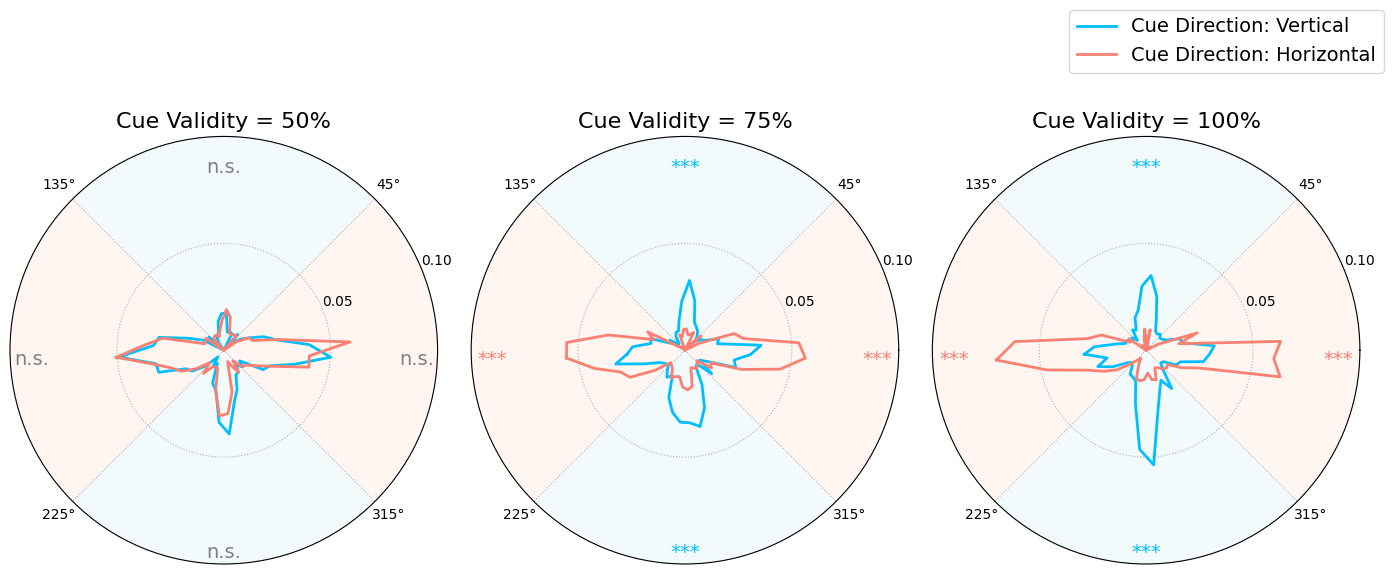

In [11]:
subj_idx = [14,15,16,17,19,20,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37]
group_df_list = []
mem = False
condition = "MEM" if mem else "STIM"

for subj in subj_idx:
    fname = f'./saccades_dataframe/data_S{subj}_nonsplit_{condition}.txt'
    df = pd.read_csv(fname)
    df['subj'] = subj
    df['state'] = condition
    group_df_list.append(df)
merged_df = pd.concat(group_df_list, ignore_index=True)
# create_radar_plot(merged_df1, use_wilcoxon=True)
create_radar_plot(merged_df,
                  use_porpotion=True,# use porpotion or count
                  use_wilcoxon=True, # use wilcoxon or ttrel
                  mc_method='fdr_bh', # mc_method='bonferroni',
                  turn_dir=False  # Turn coordinate to top and right or not
                  )

Plot Gaze Density

In [16]:
# Gaze density
from matplotlib.colors import LinearSegmentedColormap
def compute_subject_density(df_sub, x_col='new_x', y_col='new_y',
                            x_range=(-5.7, 5.7), y_range=(-5.7, 5.7),
                            bins=200):
    """
    Compute normalized 2D density for one subject in one condition.
    Returns:
        H_norm: 2D density map
        xedges, yedges
    """
    x = df_sub[x_col].to_numpy()
    y = df_sub[y_col].to_numpy()

    if len(x) == 0:
        return None, None, None

    H, xedges, yedges = np.histogram2d(
        x, y,
        bins=bins,
        range=[x_range, y_range]
    )

    # Normalize to probability density-like map
    if H.sum() > 0:
        H = H / H.sum()

    return H, xedges, yedges


def plot_gaze_density(all_df,
                      cue_values=(50, 75, 100),
                      cue_dir_values=(0, 1),
                      subj_col='subj',
                      cue_col='cue',
                      cue_dir_col='cue_direction',
                      x_col='new_x',
                      y_col='new_y',
                      time_col=None,
                      time_window=None,
                      x_range=(-5.7, 5.7),
                      y_range=(-5.7, 5.7),
                      bins=200,
                      min_trials_per_subject=1,
                      cmap='inferno',
                      vmin=None,
                      vmax=None,
                      figsize=(14, 10),
                      add_target_marker=True,
                      target_xy=None):
    """
    Plot 6 gaze density maps: cue(50/75/100) x cue_direction(0/1)

    Parameters
    ----------
    all_df : pd.DataFrame
        Must contain subj, cue, cue_direction, new_x, new_y
    time_window : tuple or None
        e.g. (0.4, 1.0). Only used if time_col is not None.
    target_xy : tuple or None
        e.g. (100, 100), if you want to mark aligned target location.
    """

    df = all_df.copy()

    # 可选：按时间窗筛选
    if (time_col is not None) and (time_window is not None):
        t0, t1 = time_window
        df = df[(df[time_col] >= t0) & (df[time_col] <= t1)].copy()

    fig, axes = plt.subplots(
        nrows=len(cue_dir_values),
        ncols=len(cue_values),
        figsize=figsize,
        sharex=True,
        sharey=True
    )

    # 防止只有1行/1列时 axes 不是二维
    axes = np.atleast_2d(axes)

    all_maps = {}

    for i, cue_val in enumerate(cue_values):
        for j, cue_dir in enumerate(cue_dir_values):

            df_cond = df[
                (df[cue_col] == cue_val) &
                (df[cue_dir_col] == cue_dir)
            ].copy()

            subj_maps = []

            for subj in df_cond[subj_col].dropna().unique():
                df_sub = df_cond[df_cond[subj_col] == subj].copy()

                # 可选：每个subject至少有一定样本数
                if len(df_sub) < min_trials_per_subject:
                    continue

                H, xedges, yedges = compute_subject_density(
                    df_sub,
                    x_col=x_col,
                    y_col=y_col,
                    x_range=x_range,
                    y_range=y_range,
                    bins=bins
                )

                if H is not None:
                    subj_maps.append(H)

            ax = axes[j, i]

            if len(subj_maps) == 0:
                ax.set_title(f'cue={cue_val}, dir={cue_dir}\n(no data)')
                ax.axis('off')
                continue

            mean_H = np.mean(np.stack(subj_maps, axis=0), axis=0)
            all_maps[(cue_val, cue_dir)] = mean_H

            # histogram2d 返回 H 的维度是 [x_bin, y_bin]
            # imshow 一般更适合用转置显示
            im = ax.imshow(
                mean_H.T,
                origin='lower',
                extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                aspect='equal',
                cmap=cmap,
                vmin=vmin,
                vmax=vmax
            )

            ax.axhline(0, linewidth=1)
            ax.axvline(0, linewidth=1)

            if add_target_marker and (target_xy is not None):
                ax.plot(target_xy[0], target_xy[1], 'wo', markersize=8,
                        markeredgecolor='k')

            ax.set_title(f'cue={cue_val}, cue_direction={cue_dir}\n(n={len(subj_maps)} subj)')

            if i == len(cue_values) - 1:
                ax.set_xlabel(x_col)
            if j == 0:
                ax.set_ylabel(y_col)

    # 统一 colorbar
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
    cbar.set_label('Mean normalized density')

    # plt.tight_layout()
    plt.show()

    return all_maps

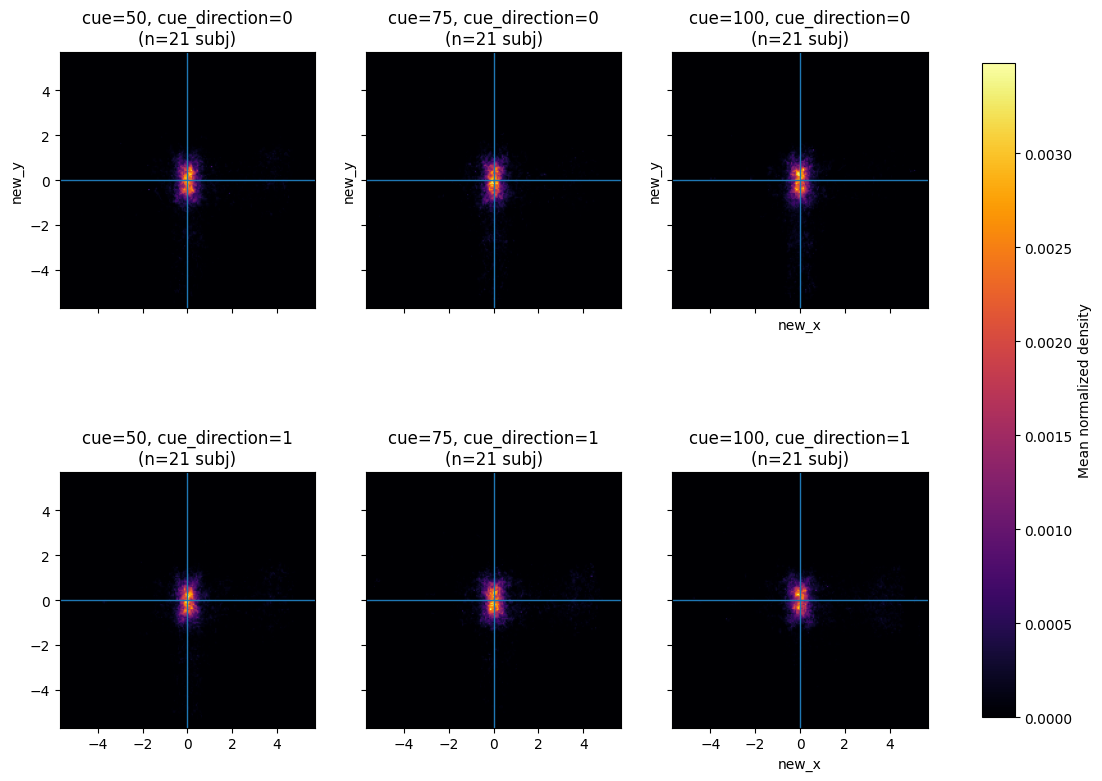

{(50,
  0): array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 (50,
  1): array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 (75,
  0): array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 (75,
  1): array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
 

In [17]:
dfs = []
mem = False
for subj in [14,15,16,17,19,20,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37]:
    df_sub = pd.read_csv(f'./gaze_location/data_S{subj}_nonsplit_{"MEM" if mem else "STIM"}.txt')
    df_sub['subj'] = subj
    dfs.append(df_sub)

all_df = pd.concat(dfs, ignore_index=True)
plot_gaze_density(all_df)

In [20]:
from matplotlib.patches import Circle


def plot_gaze_density_difference(
    all_df,
    cue_values=(50, 75, 100),
    cue_dir_values=(0, 1),   # expected two levels
    subj_col='subj',
    cue_col='cue',
    cue_dir_col='cue_direction',
    x_col='new_x',
    y_col='new_y',
    time_col=None,
    time_window=None,
    x_range=(-5.7, 5.7),
    y_range=(-5.7, 5.7),
    bins=200,
    min_samples_per_subject=10,
    figsize=(14, 4.8),
    cmap='RdBu_r',
    vmax=None,
    add_fixation=True,
    add_target_circle=True,
    target_xy=(5.7, 5.7),
    target_radius=0.6,
    xticks=None,
    yticks=None,
    save_path=None
):
    """
    For each cue value:
        mean_subject_density(cue_direction=1) - mean_subject_density(cue_direction=0)

    Returns
    -------
    diff_maps : dict
        key: cue value
        value: 2D difference map
    """

    if len(cue_dir_values) != 2:
        raise ValueError("cue_dir_values must contain exactly two levels, e.g. (0, 1).")

    dir0, dir1 = cue_dir_values
    df = all_df.copy()

    if (time_col is not None) and (time_window is not None):
        t0, t1 = time_window
        df = df[(df[time_col] >= t0) & (df[time_col] <= t1)].copy()

    fig, axes = plt.subplots(
        1, len(cue_values),
        figsize=figsize,
        sharex=True,
        sharey=True,
        constrained_layout=True
    )

    if len(cue_values) == 1:
        axes = [axes]

    diff_maps = {}
    all_diffs = []

    # ---- first pass: compute all diff maps ----
    for cue_val in cue_values:
        df_cue = df[df[cue_col] == cue_val].copy()

        subj_diffs = []
        xedges = yedges = None

        common_subjects = sorted(
            set(df_cue.loc[df_cue[cue_dir_col] == dir0, subj_col].dropna().unique())
            & set(df_cue.loc[df_cue[cue_dir_col] == dir1, subj_col].dropna().unique())
        )

        for subj in common_subjects:
            df0 = df_cue[(df_cue[subj_col] == subj) & (df_cue[cue_dir_col] == dir0)].copy()
            df1 = df_cue[(df_cue[subj_col] == subj) & (df_cue[cue_dir_col] == dir1)].copy()

            if (len(df0) < min_samples_per_subject) or (len(df1) < min_samples_per_subject):
                continue

            H0, xedges, yedges = compute_subject_density(
                df0, x_col=x_col, y_col=y_col,
                x_range=x_range, y_range=y_range, bins=bins
            )
            H1, _, _ = compute_subject_density(
                df1, x_col=x_col, y_col=y_col,
                x_range=x_range, y_range=y_range, bins=bins
            )

            if (H0 is not None) and (H1 is not None):
                subj_diffs.append(H1 - H0)

        if len(subj_diffs) == 0:
            diff_maps[cue_val] = None
            continue

        mean_diff = np.mean(np.stack(subj_diffs, axis=0), axis=0)
        diff_maps[cue_val] = {
            'map': mean_diff,
            'xedges': xedges,
            'yedges': yedges,
            'n_subj': len(subj_diffs)
        }
        all_diffs.append(mean_diff)

    # ---- choose symmetric color scale ----
    if len(all_diffs) == 0:
        print("No valid data found for any cue condition.")
        return diff_maps

    if vmax is None:
        vmax = max(np.max(np.abs(m)) for m in all_diffs)

    # ---- plotting ----
    for ax, cue_val in zip(axes, cue_values):
        info = diff_maps[cue_val]

        if info is None:
            ax.set_title(f'cue = {cue_val}\n(no valid data)')
            ax.axis('off')
            continue

        mean_diff = info['map']
        xedges = info['xedges']
        yedges = info['yedges']
        n_subj = info['n_subj']

        im = ax.imshow(
            mean_diff.T,
            origin='lower',
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
            aspect='equal',
            cmap=cmap,
            vmin=-vmax,
            vmax=vmax
        )

        if add_fixation:
            ax.axhline(0, linewidth=1)
            ax.axvline(0, linewidth=1)

        if add_target_circle and (target_xy is not None):
            circ = Circle(
                target_xy, target_radius,
                fill=False, edgecolor='white', linewidth=1.5
            )
            ax.add_patch(circ)

        ax.set_xlim(x_range)
        ax.set_ylim(y_range)

        if xticks is not None:
            ax.set_xticks(xticks)
        if yticks is not None:
            ax.set_yticks(yticks)

        ax.set_title(f'cue = {cue_val}\ndir 1 - dir 0, n = {n_subj}')
        ax.set_xlabel('Horizontal gaze position')
        if ax is axes[0]:
            ax.set_ylabel('Vertical gaze position')

    cbar = fig.colorbar(im, ax=axes, shrink=0.9)
    cbar.set_label('Mean subject-level density difference')

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()
    return diff_maps

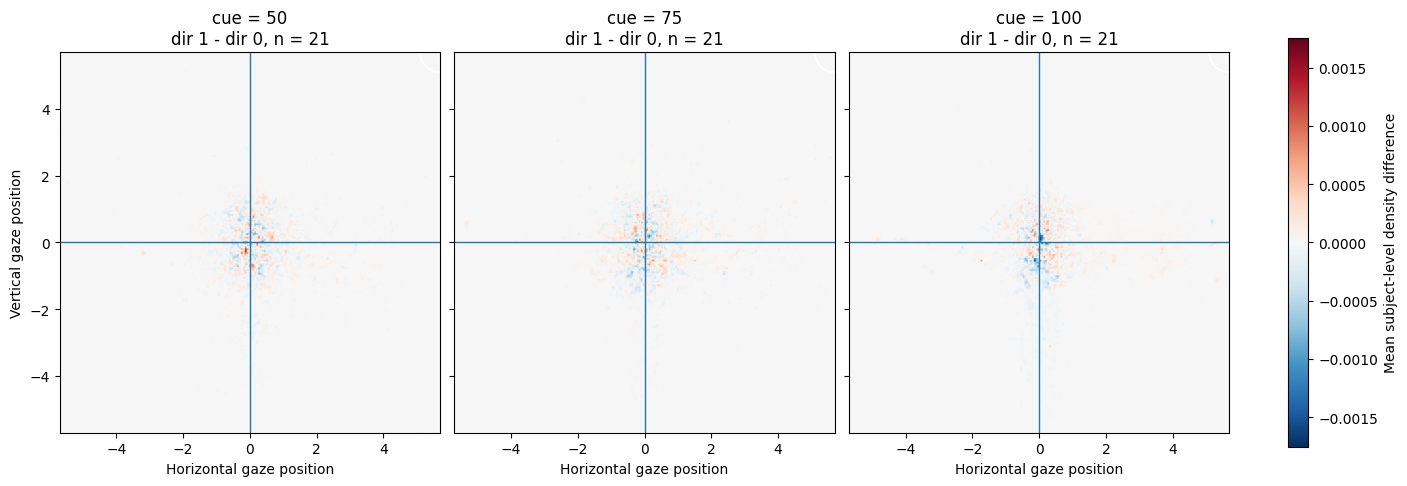

{50: {'map': array([[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]),
  'xedges': array([-5.7  , -5.643, -5.586, -5.529, -5.472, -5.415, -5.358, -5.301,
         -5.244, -5.187, -5.13 , -5.073, -5.016, -4.959, -4.902, -4.845,
         -4.788, -4.731, -4.674, -4.617, -4.56 , -4.503, -4.446, -4.389,
         -4.332, -4.275, -4.218, -4.161, -4.104, -4.047, -3.99 , -3.933,
         -3.876, -3.819, -3.762, -3.705, -3.648, -3.591, -3.534, -3.477,
         -3.42 , -3.363, -3.306, -3.249, -3.192, -3.135, -3.078, -3.021,
         -2.964, -2.907, -2.85 , -2.793, -2.736, -2.679, -2.622, -2.565,
         -2.508, -2.451, -2.394, -2.337, -2.28 , -2.223, -2.166, -2.109,
         -2.052, -1.995, -1.938, -1.881, -1.824, -1.767, -1.71 , -1.653,
         -1.596, -1.539, -1.482, -1.425, -1.368, -1.311, -1.254, -

In [23]:
dfs = []
mem = True
for subj in [14,15,16,17,19,20,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37]:
    df_sub = pd.read_csv(f'./gaze_location/data_S{subj}_nonsplit_{"MEM" if mem else "STIM"}.txt')
    df_sub['subj'] = subj
    dfs.append(df_sub)

all_df = pd.concat(dfs, ignore_index=True)
plot_gaze_density_difference(all_df)